# Classification Using Pretrained Bioclinical Bert

In [1]:
import json
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from deep_utils import DirUtils, StringUtils, JsonUtils
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

CSV_PATH = "./sampled_1000_data.csv"
TEXT_COL = "radgraph_json_info"  # column with full report text
LABEL_COL = "class_list"  # column with 75-length label vector

NUM_LABELS = 75  # 75 outcomes per report
NUM_CLASSES = 3  # {-1,0,1} → {0,1,2}
MAX_LEN = 512
BATCH_SIZE = 4
LR = 2e-5
EPOCHS = 20

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"


### load Data and Map labels

In [3]:
df = pd.read_csv(CSV_PATH)
def parse_label_vector(s):
    """
    s: string like '[-1.0, 1.0, 0.0, ...]'.
    Returns a list[int] length 75 with values in {0,1,2},
    mapping -1→0, 0→1, 1→2.
    """
    arr = np.array(json.loads(s))  # e.g. shape (75,)
    if len(arr) != NUM_LABELS:
        raise ValueError(f"Expected {NUM_LABELS} labels, got {len(arr)}")
    mapped = arr.astype(int) + 1  # -1→0, 0→1, 1→2
    return mapped.tolist()


df["label_vector"] = df[LABEL_COL].apply(parse_label_vector)

### split data into Train/validation/Test

In [4]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
val_df, test_df = train_test_split(val_df, test_size=0.5, random_state=42, shuffle=True)

print("Train size:", len(train_df), "Val size:", len(val_df), "Test size:", len(test_df))

Train size: 800 Val size: 100 Test size: 100


In [5]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


# Dataset

class RadiologyReportDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512):
        self.texts = df[TEXT_COL].tolist()
        self.labels = df["label_vector"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        labels = torch.tensor(self.labels[idx], dtype=torch.long)  # (75,)

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels
        }


train_dataset = RadiologyReportDataset(train_df, tokenizer, MAX_LEN)
val_dataset = RadiologyReportDataset(val_df, tokenizer, MAX_LEN)
test_dataset = RadiologyReportDataset(test_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Adding Classification layer on top of Pretrained Encoder

In [6]:
# Model: ClinicalBERT + 75×3 head

class MultiHeadClinicalBERT(nn.Module):
    def __init__(self, model_name, num_labels=75, num_classes=3, dropout=0.1):
        super().__init__()
        self.num_labels = num_labels
        self.num_classes = num_classes

        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size  # usually 768

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels * num_classes)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # CLS embedding
        cls_emb = outputs.last_hidden_state[:, 0, :]  # (B, H)
        cls_emb = self.dropout(cls_emb)

        logits = self.classifier(cls_emb)  # (B, 75*3)
        logits = logits.view(-1, self.num_labels, self.num_classes)  # (B, 75, 3)

        loss = None
        if labels is not None:
            # labels: (B, 75) with integers in {0,1,2}
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(
                logits.view(-1, self.num_classes),  # (B*75, 3)
                labels.view(-1)  # (B*75,)
            )
        return loss, logits


model = MultiHeadClinicalBERT(MODEL_NAME, NUM_LABELS, NUM_CLASSES)
model.to(DEVICE)

MultiHeadClinicalBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

### Freezing Bert

In [7]:
# freeze bert
StringUtils.print("Setting bert to freeze", color="green")
for p in model.bert.parameters():
    p.requires_grad_(False)
# Optimizer & scheduler

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

Setting bert to freeze


### Training and Validation Loop

In [8]:
# Training & validation

def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)  # (B, 75)

        optimizer.zero_grad()
        loss, logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


@torch.no_grad()
def eval_one_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        loss, logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        total_loss += loss.item()

        preds = logits.argmax(dim=-1)  # (B, 75)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    avg_loss = total_loss / len(dataloader)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    return avg_loss, all_preds, all_labels


def multi_f1_score(y_true, y_pred):
    f1_scores_macro = []
    for i in range(y_true.shape[1]):
        f1 = f1_score(y_true[:, i], y_pred[:, i], average='macro')
        f1_scores_macro.append(f1)

    mean_f1_macro = np.mean(f1_scores_macro)
    return mean_f1_macro


In [9]:
# 8. Run training

val_loss_values = []
train_loss_values = []
f1_score_values = []
best_f1_score = 0
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_preds, val_labels = eval_one_epoch(model, val_loader, DEVICE)
    val_loss_values.append(val_loss)
    train_loss_values.append(train_loss)
    print(val_labels.shape, val_preds.shape, np.unique(val_preds))
    val_f1_score = multi_f1_score(val_labels, val_preds)

    if val_f1_score > best_f1_score:
        torch.save(model.state_dict(), "./clinicalbert_75x3_best.pt")
        best_f1_score = val_f1_score

    f1_score_values.append(val_f1_score)
    torch.save(model.state_dict(), "./clinicalbert_75x3_last.pt")
    # print("Model saved to clinicalbert_75x3_last.pt")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val   loss: {val_loss:.4f}")
    print(f"  Val   f1_score: {val_f1_score:.4f}")
    test_loss, test_preds, test_labels = eval_one_epoch(model, test_loader, DEVICE)
test_f1_score = multi_f1_score(test_labels, test_preds)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

(100, 75) (100, 75) [0 1 2]
Epoch 1/20
  Train loss: 1.0701
  Val   loss: 0.9361
  Val   f1_score: 0.3491
(100, 75) (100, 75) [0 1]
Epoch 2/20
  Train loss: 0.7415
  Val   loss: 0.5718
  Val   f1_score: 0.5096
(100, 75) (100, 75) [0 1]
Epoch 3/20
  Train loss: 0.4540
  Val   loss: 0.3915
  Val   f1_score: 0.5117
(100, 75) (100, 75) [0 1]
Epoch 4/20
  Train loss: 0.3471
  Val   loss: 0.3247
  Val   f1_score: 0.5117
(100, 75) (100, 75) [0 1 2]
Epoch 5/20
  Train loss: 0.3043
  Val   loss: 0.2937
  Val   f1_score: 0.5125
(100, 75) (100, 75) [0 1 2]
Epoch 6/20
  Train loss: 0.2837
  Val   loss: 0.2769
  Val   f1_score: 0.5133
(100, 75) (100, 75) [0 1 2]
Epoch 7/20
  Train loss: 0.2730
  Val   loss: 0.2665
  Val   f1_score: 0.5133
(100, 75) (100, 75) [0 1 2]
Epoch 8/20
  Train loss: 0.2644
  Val   loss: 0.2597
  Val   f1_score: 0.5140
(100, 75) (100, 75) [0 1 2]
Epoch 9/20
  Train loss: 0.2596
  Val   loss: 0.2549
  Val   f1_score: 0.5143
(100, 75) (100, 75) [0 1 2]
Epoch 10/20
  Train loss

### Fintune Encoder & Classifier

Setting bert to finetune
(100, 75) (100, 75) [0 1 2]
Epoch 1/80
  Train loss: 0.2448
  Val   loss: 0.2347
  Val   f1_score: 0.5164
(100, 75) (100, 75) [0 1 2]
Epoch 2/80
  Train loss: 0.2380
  Val   loss: 0.2233
  Val   f1_score: 0.5256
(100, 75) (100, 75) [0 1 2]
Epoch 3/80
  Train loss: 0.2232
  Val   loss: 0.2096
  Val   f1_score: 0.5432
(100, 75) (100, 75) [0 1 2]
Epoch 4/80
  Train loss: 0.2081
  Val   loss: 0.1929
  Val   f1_score: 0.5490
(100, 75) (100, 75) [0 1 2]
Epoch 5/80
  Train loss: 0.1920
  Val   loss: 0.1786
  Val   f1_score: 0.5718
(100, 75) (100, 75) [0 1 2]
Epoch 6/80
  Train loss: 0.1766
  Val   loss: 0.1662
  Val   f1_score: 0.5863
(100, 75) (100, 75) [0 1 2]
Epoch 7/80
  Train loss: 0.1604
  Val   loss: 0.1540
  Val   f1_score: 0.6051
(100, 75) (100, 75) [0 1 2]
Epoch 8/80
  Train loss: 0.1470
  Val   loss: 0.1452
  Val   f1_score: 0.6227
(100, 75) (100, 75) [0 1 2]
Epoch 9/80
  Train loss: 0.1341
  Val   loss: 0.1373
  Val   f1_score: 0.6312
(100, 75) (100, 75) [

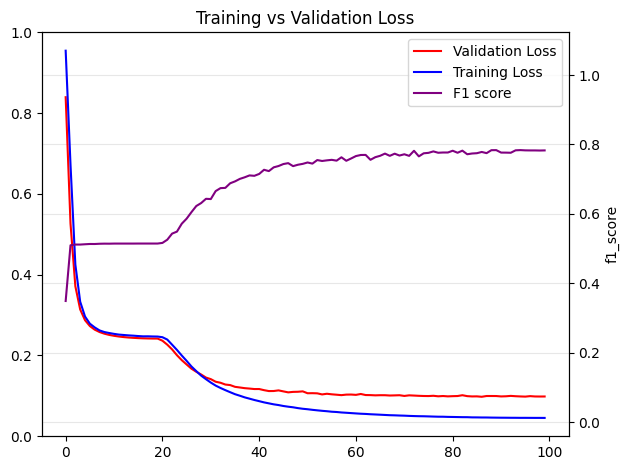

In [10]:
# finetune bert
StringUtils.print("Setting bert to finetune", color='green')
for p in model.bert.parameters():
    p.requires_grad_(True)
# Optimizer & scheduler
LR /= 2
EPOCHS = 80
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# ===============================
# 9. Run training
# ===============================
# val_loss_values = []
# train_loss_values = []

# best_f1_score = 0
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_preds, val_labels = eval_one_epoch(model, val_loader, DEVICE)
    val_loss_values.append(val_loss)
    train_loss_values.append(train_loss)
    print(val_labels.shape, val_preds.shape, np.unique(val_preds))
    val_f1_score = multi_f1_score(val_labels, val_preds)
    f1_score_values.append(val_f1_score)

    if val_f1_score > best_f1_score:
        torch.save(model.state_dict(), "./clinicalbert_75x3_finetune_both_best.pt")
        best_f1_score = val_f1_score

    torch.save(model.state_dict(), "./clinicalbert_75x3_finetune_both_last.pt")
    # print("Model saved to clinicalbert_75x3_last.pt")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val   loss: {val_loss:.4f}")
    print(f"  Val   f1_score: {val_f1_score:.4f}")

plt2 = plt.twinx()

plt.plot(val_loss_values, color='red', label='Validation Loss')
plt.plot(train_loss_values, color='blue', label='Training Loss')
plt.legend(loc='upper left')
# Add labels and title for clarity
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt2.plot(f1_score_values, color='Purple', label='F1 score')
plt2.legend(loc='upper right')


plt2.set_ylabel("f1_score")
plt.title('Training vs Validation Loss')
plt.tight_layout()
plt.grid(True, alpha=0.3)

plt.savefig("loss_finetune_both.png")

test_loss, test_preds, test_labels = eval_one_epoch(model, test_loader, DEVICE)
test_f1_score = multi_f1_score(test_labels, test_preds)
JsonUtils.dump("test_finetune_both_preds.json", test_preds.tolist())
JsonUtils.dump("test_finetune_both_labels.json", test_labels.tolist())
DirUtils.write_txt("./test_finetune_both_f1_score.txt", [f'{test_f1_score}'], mode="w")
print(test_f1_score)

In [12]:

JsonUtils.dump("test_finetune_both_preds.json", test_preds.tolist())
JsonUtils.dump("test_finetune_both_labels.json", test_labels.tolist())

y_true shape: (7500,)
y_pred shape: (7500,)
Confusion matrix:
 [[6776    4   26]
 [  11  238    9]
 [  93    7  336]]


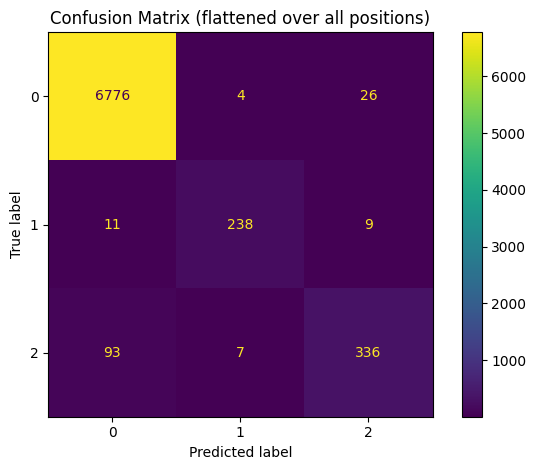

In [19]:
labels="new_train_with_tests/new_train_with_tests/freeze-finetune/test_labels.json"
preds="new_train_with_tests/new_train_with_tests/freeze-finetune/test_preds.json"

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load JSON files
y_true = np.array(JsonUtils.load("test_finetune_both_labels.json")).reshape(-1)
y_pred = np.array(JsonUtils.load("test_finetune_both_preds.json")).reshape(-1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)



# 🔹 Compute confusion matrix for classes 0, 1, 2
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
print("Confusion matrix:\n", cm)

# 🔹 Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(values_format='d')
plt.title("Confusion Matrix (flattened over all positions)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()